# Section 3: The Three-Country Model

This notebook reproduces the results and figures from Section 3 of *Trade Tariffs and Exchange Rates: Revisiting Conventional Wisdom in a Three-Country Framework* (Lu & Milkov 2026).

We extend the two-country model to three countries and show that the conventional appreciation result **breaks down** when tariffs are applied selectively. The three-country setting introduces opposing trade-diversion and trade-redirection forces whose relative strength determines the sign and magnitude of the exchange rate response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tariff_exchange_rates import (
    make_params_3country,
    solve_3country,
    plot_equilibria,
    make_tariff_matrix,
    free_trade, uniform_tariff, isolated_tariff, trade_war,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 4.1 Model Setup

Three countries $\{A, B, C\}$ each produce one tradable variety $T_i$ and one non-tradable $N_i$ using labor. Technologies are linear and producer prices are normalized to one.

Households have **nested preferences**:
- **Outer layer**: Cobb-Douglas over the tradable bundle and non-tradables, with fixed shares $\alpha_T$ and $\alpha_N = 1 - \alpha_T$
- **Inner layer**: CES over the three tradable varieties with elasticity of substitution $\sigma$

$$C_{T_i} = \left[\sum_{j} \alpha_{T_j}^{1/\sigma} C_{T_j i}^{\frac{\sigma-1}{\sigma}}\right]^{\frac{\sigma}{\sigma-1}}$$

The **exchange rate matrix** satisfies no-arbitrage: $e_{ij} = e_{ik} e_{kj}$. Two free rates $(e_{AB}, e_{AC})$ pin down all others. Equilibrium is characterized by $\mathrm{TB}_B = \mathrm{TB}_C = 0$; $\mathrm{TB}_A = 0$ follows from Walras' law.

Country $i$ applies tariff $\tau_{ij}$ on imports from $j$. Tariff revenue is rebated lump-sum. Disposable income is:

$$I_i = \frac{w_i L_i}{1 - \displaystyle\sum_j \alpha_{T_j}\, \dfrac{\tau_{ij}}{1+\tau_{ij}}}$$

In [2]:
# Symmetric baseline calibration from the paper
# A_T = A_N = 1, L = 1, equal shares (1/4 each), sigma = 1 (Cobb-Douglas)
params_cd = make_params_3country(
    alpha_T_A=0.25, alpha_T_B=0.25, alpha_T_C=0.25, alpha_N=0.25,
    sigma=1.0,
)

# Free-trade equilibrium
eq_ft = solve_3country(params_cd, free_trade())
print("Free-trade equilibrium (symmetric baseline):")
print(f"  e_AB = {eq_ft['e_AB']:.4f}  (by symmetry, = 1)")
print(f"  e_AC = {eq_ft['e_AC']:.4f}")
print(f"  e_BC = {eq_ft['e_BC']:.4f}")

Free-trade equilibrium (symmetric baseline):
  e_AB = 1.0000  (by symmetry, = 1)
  e_AC = 1.0000
  e_BC = 1.0000


## 4.2 Equilibrium Visualization: Free Trade (Figure 2)

The figure below plots the **balanced-trade loci** for countries $B$ and $C$ in $(e_{AB}, e_{AC})$ space. Equilibrium is at the intersection. By symmetry, the two loci are mirror images and the equilibrium is at $e_{AB} = e_{AC} = 1$.

The four quadrants correspond to different combinations of trade imbalances — bottom-left is where both $B$ and $C$ run surpluses against $A$ (overvalued $A$ currency); top-right is the reverse.

Saved: ../output/3c2s1f_CD_free_trade.pdf


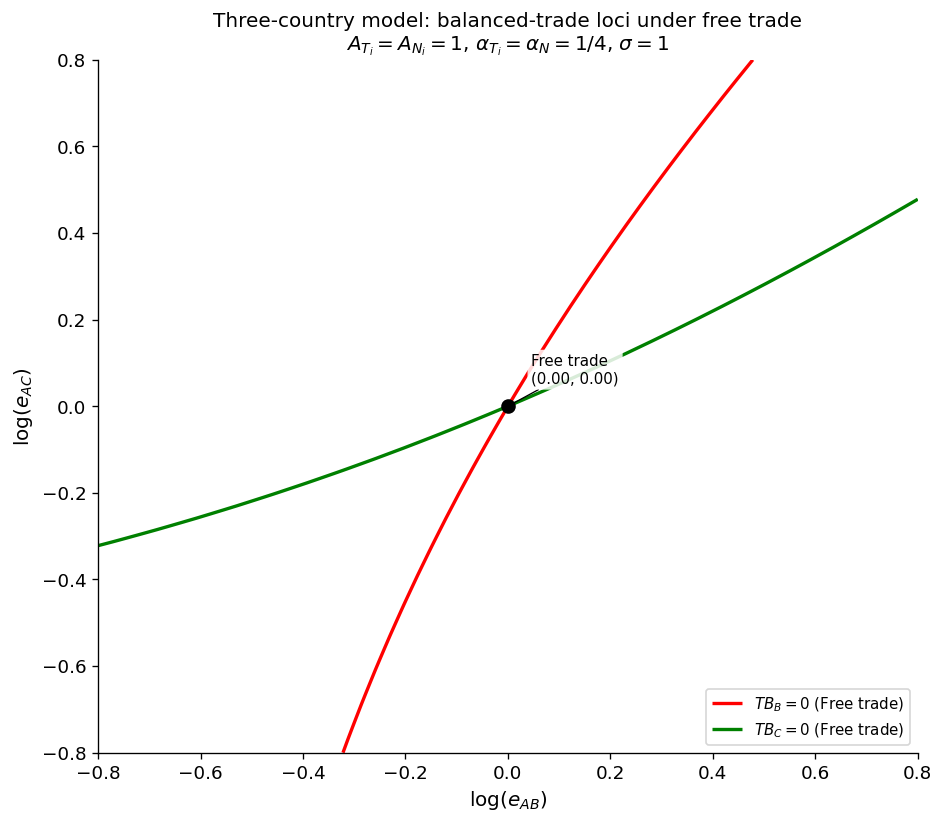

In [3]:
plot_equilibria(
    params_cd,
    tariff_scenarios={"Free trade": free_trade()},
    tb_pair=("B", "C"),
    coord1=("A", "B"), coord2=("A", "C"),
    log_eAB_range=(-0.8, 0.8),
    log_eAC_range=(-0.8, 0.8),
    n_grid=60,
    title="Three-country model: balanced-trade loci under free trade\n"
          r"$A_{T_i}=A_{N_i}=1$, $\alpha_{T_i}=\alpha_N=1/4$, $\sigma=1$",
    pdf_name="../output/3c2s1f_CD_free_trade.pdf",
)

## 4.3 Experiment 1: Uniform Tariffs — The Two-Country Analogue

Country $A$ imposes the **same tariff** $\tau$ on both $B$ and $C$: $\tau_{AB} = \tau_{AC} = \tau$.

This is the natural three-country analogue of the two-country benchmark. Because the tariff is symmetric across foreign suppliers, **both** balanced-trade loci shift outward together, and the equilibrium shifts along the 45-degree line — $A$'s currency appreciates equally against both $B$ and $C$.

> **Result**: Uniform tariffs replicate the conventional appreciation result. The sign is unambiguous regardless of $\sigma$.

Saved: ../output/3c2s1f_CD_uniform_tariff.pdf


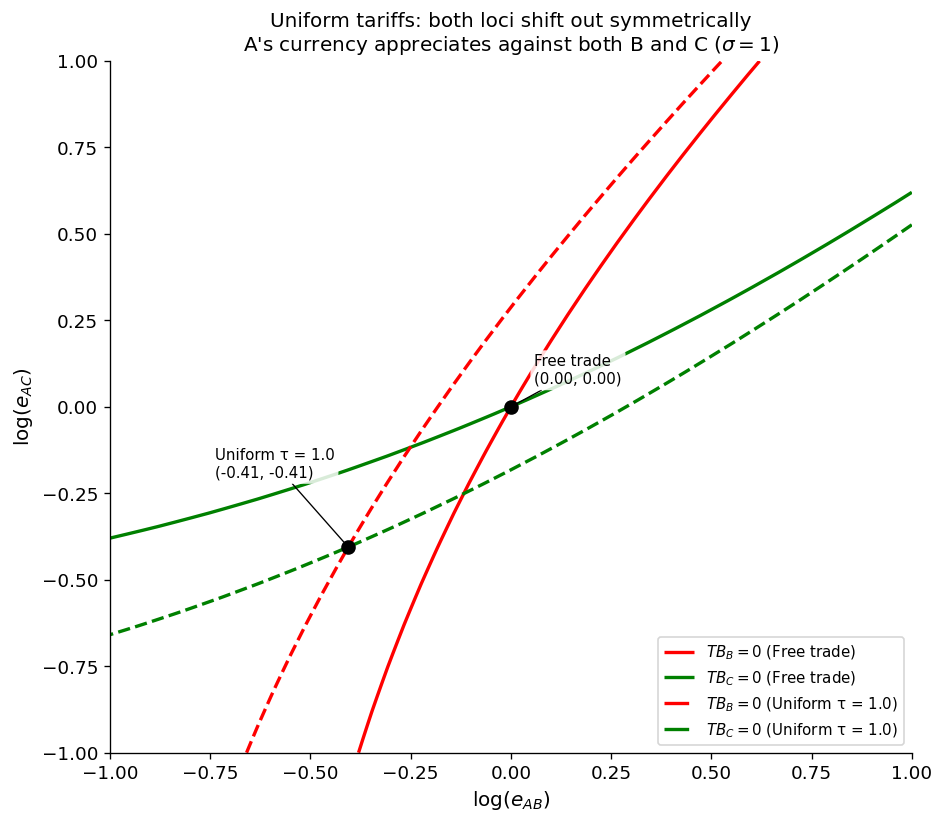

Free trade            e_AB=1.0000  e_AC=1.0000  e_BC=1.0000
Uniform τ=1.0         e_AB=0.6667  e_AC=0.6667  e_BC=1.0000


In [4]:
plot_equilibria(
    params_cd,
    tariff_scenarios={
        "Free trade":       free_trade(),
        "Uniform τ = 1.0": uniform_tariff(1.0),
    },
    tb_pair=("B", "C"),
    coord1=("A", "B"), coord2=("A", "C"),
    log_eAB_range=(-1.0, 1.0),
    log_eAC_range=(-1.0, 1.0),
    title="Uniform tariffs: both loci shift out symmetrically\n"
          r"A's currency appreciates against both B and C ($\sigma=1$)",
    pdf_name="../output/3c2s1f_CD_uniform_tariff.pdf",
)

# Print equilibrium values
for label, T in [("Free trade", free_trade()), ("Uniform τ=1.0", uniform_tariff(1.0))]:
    eq = solve_3country(params_cd, T)
    print(f"{label:20s}  e_AB={eq['e_AB']:.4f}  e_AC={eq['e_AC']:.4f}  e_BC={eq['e_BC']:.4f}")

## 4.4 Experiment 2: Isolated Tariff — The Ambiguous Case

Country $A$ imposes tariff $\tau$ on $B$ **only**: $\tau_{AB} = \tau$, $\tau_{AC} = 0$. This breaks symmetry and introduces a new margin of adjustment absent in the uniform case.

Two **opposing forces** now operate:

1. **Trade-diversion effect**: Imports into $A$ are reallocated away from $B$ toward $C$, raising demand for $C$'s exports → appreciation pressure on $C$'s currency (higher $e_{AC}$, i.e. $A$ depreciates against $C$)

2. **Trade-redirection effect**: $B$ loses access to $A$'s market and reallocates exports toward $C$, increasing $C$'s imports → depreciation pressure on $C$'s currency (lower $e_{AC}$, i.e. $A$ appreciates against $C$)

The **elasticity of substitution $\sigma$** governs which force dominates:
- Low $\sigma$: goods are complements, diversion is small → redirection dominates → $A$ appreciates against $C$
- High $\sigma$: goods are substitutes, diversion is large → diversion dominates → $A$ depreciates against $C$

> **Result**: The exchange rate response is **ambiguous**. Bilateral appreciation against $B$ can coexist with depreciation against $C$.

Saved: ../output/3c2s1f_CD_isolated_tariff.pdf


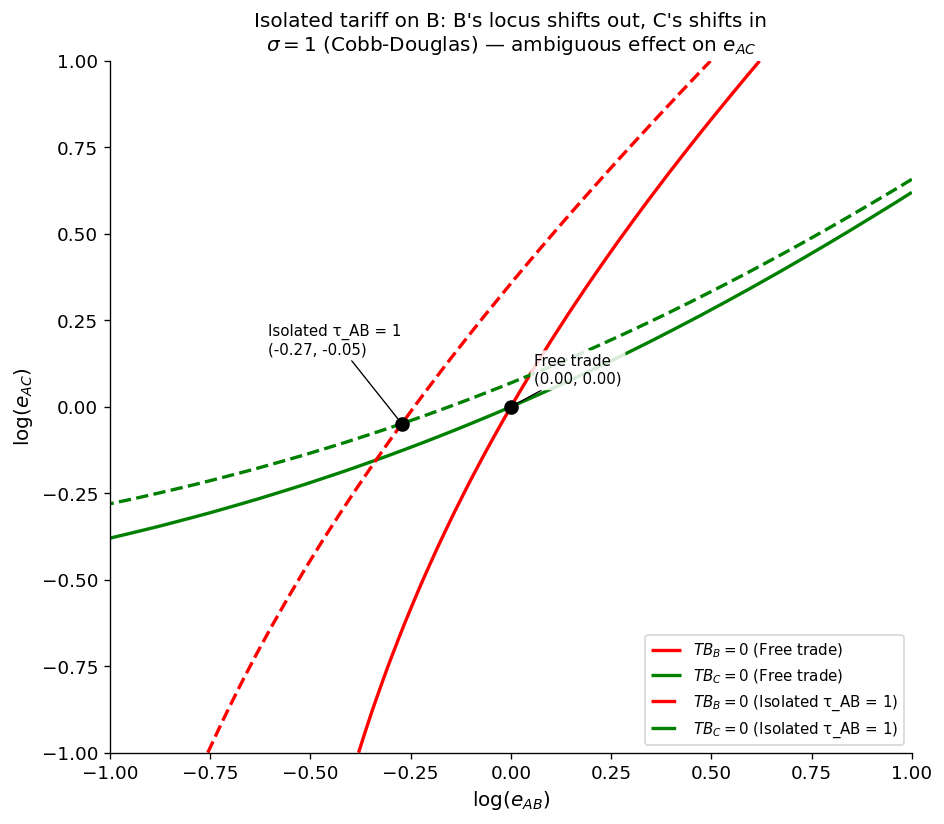

Free trade              e_AB=1.0000  e_AC=1.0000  e_BC=1.0000
Isolated τ_AB=1         e_AB=0.7619  e_AC=0.9524  e_BC=1.2500


In [5]:
# Cobb-Douglas (sigma=1): baseline isolated tariff
plot_equilibria(
    params_cd,
    tariff_scenarios={
        "Free trade":         free_trade(),
        "Isolated τ_AB = 1": isolated_tariff(1.0),
    },
    tb_pair=("B", "C"),
    coord1=("A", "B"), coord2=("A", "C"),
    log_eAB_range=(-1.0, 1.0),
    log_eAC_range=(-1.0, 1.0),
    title="Isolated tariff on B: B's locus shifts out, C's shifts in\n"
          r"$\sigma=1$ (Cobb-Douglas) — ambiguous effect on $e_{AC}$",
    pdf_name="../output/3c2s1f_CD_isolated_tariff.pdf",
)

for label, T in [("Free trade", free_trade()), ("Isolated τ_AB=1", isolated_tariff(1.0))]:
    eq = solve_3country(params_cd, T)
    print(f"{label:22s}  e_AB={eq['e_AB']:.4f}  e_AC={eq['e_AC']:.4f}  e_BC={eq['e_BC']:.4f}")

Saved: ../output/3c2s1f_CES05_isolated_tariff.pdf


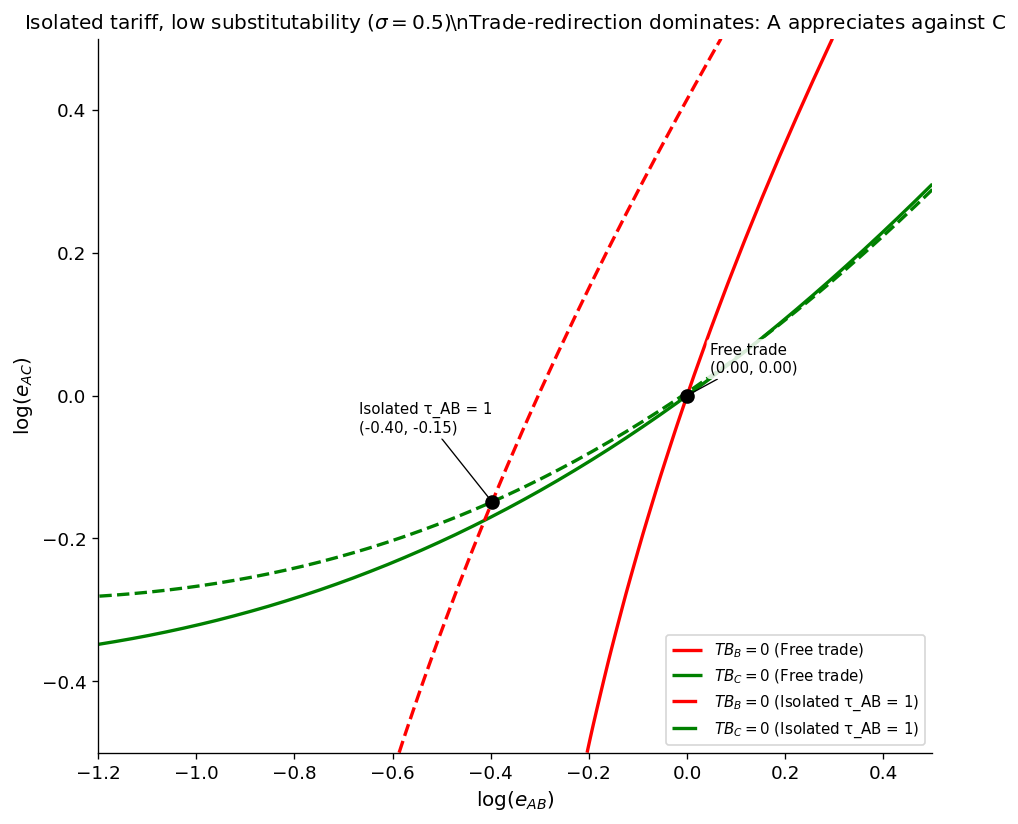

Free trade              e_AB=1.0000  e_AC=1.0000  (A appreciates vs C)


Isolated τ_AB=1         e_AB=0.6722  e_AC=0.8617  (A appreciates vs C)


In [6]:
# Low sigma = 0.5: redirection dominates, A appreciates against C
params_ces05 = make_params_3country(
    alpha_T_A=0.25, alpha_T_B=0.25, alpha_T_C=0.25, alpha_N=0.25,
    sigma=0.5,
)

plot_equilibria(
    params_ces05,
    tariff_scenarios={
        "Free trade":         free_trade(),
        "Isolated τ_AB = 1": isolated_tariff(1.0),
    },
    tb_pair=("B", "C"),
    coord1=("A", "B"), coord2=("A", "C"),
    log_eAB_range=(-1.2, 0.5),
    log_eAC_range=(-0.5, 0.5),
    title=r"Isolated tariff, low substitutability ($\sigma = 0.5$)\n"
          "Trade-redirection dominates: A appreciates against C",
    pdf_name="../output/3c2s1f_CES05_isolated_tariff.pdf",
)

for label, T in [("Free trade", free_trade()), ("Isolated τ_AB=1", isolated_tariff(1.0))]:
    eq = solve_3country(params_ces05, T)
    pct = 100*(eq['e_AC'] - 1.0)
    direction = "(A depreciates vs C)" if pct > 0 else "(A appreciates vs C)"
    print(f"{label:22s}  e_AB={eq['e_AB']:.4f}  e_AC={eq['e_AC']:.4f}  {direction}")

Saved: ../output/3c2s1f_CES2_isolated_tariff.pdf


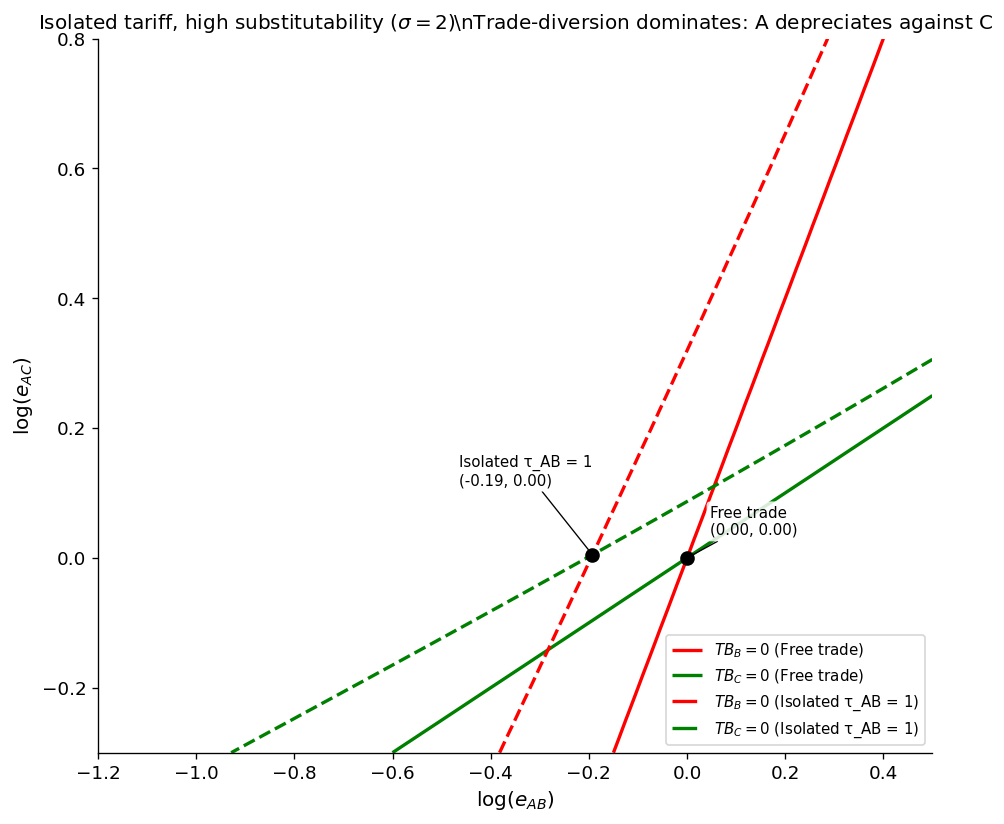

Free trade              e_AB=1.0000  e_AC=1.0000  (A appreciates vs C)
Isolated τ_AB=1         e_AB=0.8247  e_AC=1.0048  (A depreciates vs C)


In [7]:
# High sigma = 2: diversion dominates, A depreciates against C
params_ces2 = make_params_3country(
    alpha_T_A=0.25, alpha_T_B=0.25, alpha_T_C=0.25, alpha_N=0.25,
    sigma=2.0,
)

plot_equilibria(
    params_ces2,
    tariff_scenarios={
        "Free trade":         free_trade(),
        "Isolated τ_AB = 1": isolated_tariff(1.0),
    },
    tb_pair=("B", "C"),
    coord1=("A", "B"), coord2=("A", "C"),
    log_eAB_range=(-1.2, 0.5),
    log_eAC_range=(-0.3, 0.8),
    title=r"Isolated tariff, high substitutability ($\sigma = 2$)\n"
          "Trade-diversion dominates: A depreciates against C",
    pdf_name="../output/3c2s1f_CES2_isolated_tariff.pdf",
)

for label, T in [("Free trade", free_trade()), ("Isolated τ_AB=1", isolated_tariff(1.0))]:
    eq = solve_3country(params_ces2, T)
    pct = 100*(eq['e_AC'] - 1.0)
    direction = "(A depreciates vs C)" if pct > 0 else "(A appreciates vs C)"
    print(f"{label:22s}  e_AB={eq['e_AB']:.4f}  e_AC={eq['e_AC']:.4f}  {direction}")

### The Role of Sigma: Scanning the Full Range

To see the transition clearly, we plot $e_{AC}$ as a function of $\sigma$ for a fixed isolated tariff $\tau_{AB} = 1$.

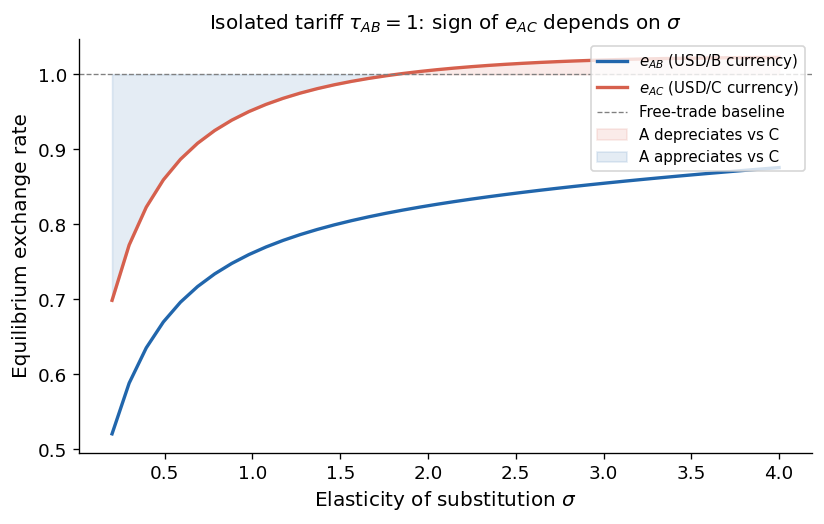

e_AC crosses 1.0 (conventional reversal) near σ ≈ 1.86
  e_AB is always below 1.0 (A always appreciates vs B): True


In [8]:
sigmas = np.linspace(0.2, 4.0, 40)
e_AC_vals = []
e_AB_vals = []

for s in sigmas:
    p = make_params_3country(
        alpha_T_A=0.25, alpha_T_B=0.25, alpha_T_C=0.25, alpha_N=0.25,
        sigma=s,
    )
    eq = solve_3country(p, isolated_tariff(1.0))
    e_AC_vals.append(eq["e_AC"])
    e_AB_vals.append(eq["e_AB"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sigmas, e_AB_vals, color="#2166ac", linewidth=2, label=r"$e_{AB}$ (USD/B currency)")
ax.plot(sigmas, e_AC_vals, color="#d6604d", linewidth=2, label=r"$e_{AC}$ (USD/C currency)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Free-trade baseline")
ax.fill_between(sigmas, e_AC_vals, 1.0,
                where=[v > 1.0 for v in e_AC_vals],
                alpha=0.12, color="#d6604d", label="A depreciates vs C")
ax.fill_between(sigmas, e_AC_vals, 1.0,
                where=[v < 1.0 for v in e_AC_vals],
                alpha=0.12, color="#2166ac", label="A appreciates vs C")
ax.set_xlabel(r"Elasticity of substitution $\sigma$", fontsize=12)
ax.set_ylabel("Equilibrium exchange rate", fontsize=12)
ax.set_title(r"Isolated tariff $\tau_{AB}=1$: sign of $e_{AC}$ depends on $\sigma$", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Find the crossover sigma
crossover = sigmas[np.argmin(np.abs(np.array(e_AC_vals) - 1.0))]
print(f"e_AC crosses 1.0 (conventional reversal) near σ ≈ {crossover:.2f}")
print(f"  e_AB is always below 1.0 (A always appreciates vs B): {all(v < 1.0 for v in e_AB_vals)}")

## 4.5 Experiment 3: Bilateral Trade War — The Amplification Case

Countries $A$ and $B$ impose reciprocal tariffs: $\tau_{AB} = \tau_{BA} = \tau$. Country $C$ is uninvolved.

This restores symmetry between $A$ and $B$. Both countries now face elevated barriers to trade with each other, while $C$ remains a freely accessible trading partner. The two opposing forces from the isolated case now **reinforce** each other:
- $A$ diverts imports away from $B$ toward $C$
- $B$ also diverts imports away from $A$ toward $C$
- Both countries redirect exports away from the tariff-affected bilateral relationship toward $C$'s market

> **Result**: Both $A$'s and $B$'s currencies **unambiguously depreciate** relative to $C$, regardless of $\sigma$. The bilateral rate $e_{AB}$ is unchanged by symmetry. The magnitude of depreciation against $C$ is increasing in $\sigma$.

We plot in $(e_{AC}, e_{BC})$ space to make the joint depreciation against $C$ visible.

Saved: ../output/3c2s1f_CD_trade_war.pdf


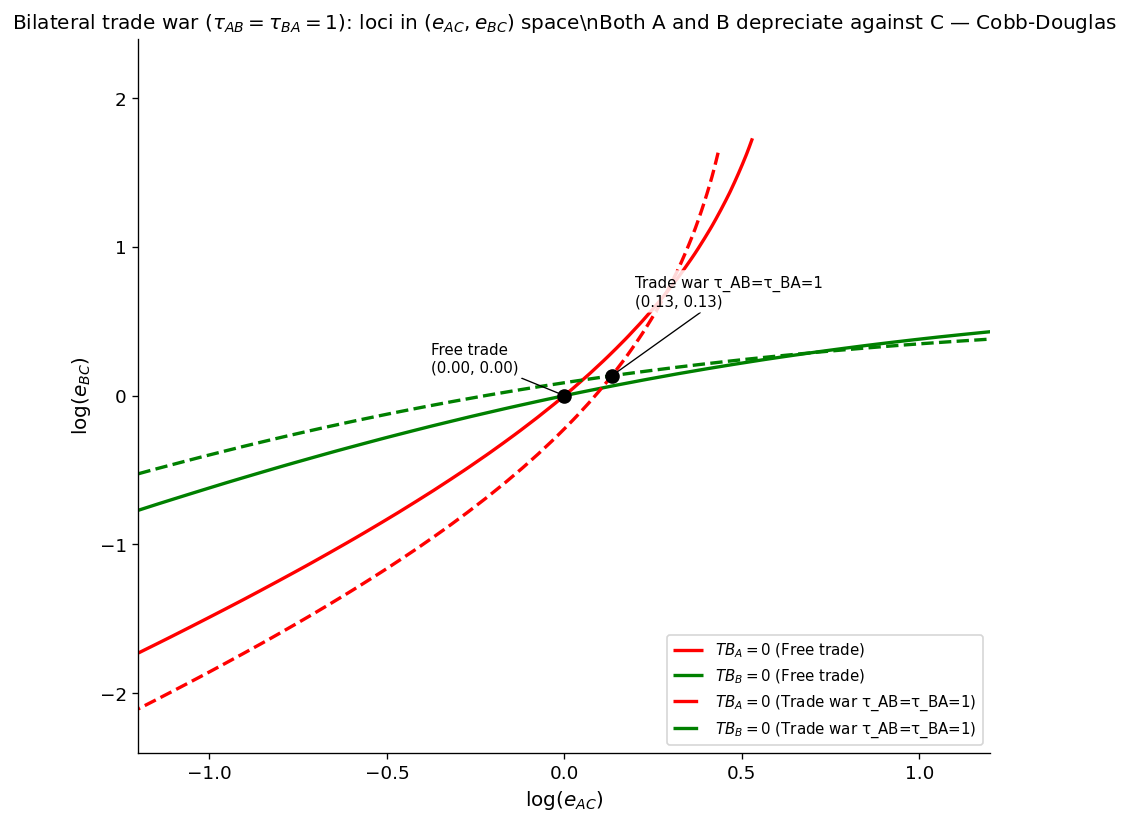

Free trade              e_AB=1.0000  e_AC=1.0000  e_BC=1.0000
Trade war τ=1           e_AB=1.0000  e_AC=1.1429  e_BC=1.1429


In [9]:
plot_equilibria(
    params_cd,
    tariff_scenarios={
        "Free trade":           free_trade(),
        "Trade war τ_AB=τ_BA=1": trade_war(1.0),
    },
    tb_pair=("A", "B"),
    coord1=("A", "C"), coord2=("B", "C"),
    log_eAB_range=(-1.2, 1.2),
    log_eAC_range=(-1.2, 1.2),
    title=r"Bilateral trade war ($\tau_{AB}=\tau_{BA}=1$): loci in $(e_{AC}, e_{BC})$ space\n"
          "Both A and B depreciate against C — Cobb-Douglas",
    pdf_name="../output/3c2s1f_CD_trade_war.pdf",
)

for label, T in [("Free trade", free_trade()), ("Trade war τ=1", trade_war(1.0))]:
    eq = solve_3country(params_cd, T)
    print(f"{label:22s}  e_AB={eq['e_AB']:.4f}  e_AC={eq['e_AC']:.4f}  e_BC={eq['e_BC']:.4f}")

In [10]:
# Verify: both A and B depreciate against C across all sigma
sigmas_war = [0.5, 1.0, 2.0, 4.0]
print("Trade war τ_AB = τ_BA = 1.0: equilibrium exchange rates")
print(f"{'σ':>5}  {'e_AB':>8}  {'e_AC':>8}  {'e_BC':>8}  {'A vs C':>12}  {'B vs C':>12}")
for s in sigmas_war:
    p = make_params_3country(
        alpha_T_A=0.25, alpha_T_B=0.25, alpha_T_C=0.25, alpha_N=0.25, sigma=s
    )
    eq = solve_3country(p, trade_war(1.0))
    a_vs_c = "A depreciates" if eq['e_AC'] > 1 else "A appreciates"
    b_vs_c = "B depreciates" if eq['e_BC'] > 1 else "B appreciates"
    print(f"{s:5.1f}  {eq['e_AB']:8.4f}  {eq['e_AC']:8.4f}  {eq['e_BC']:8.4f}  {a_vs_c:>12}  {b_vs_c:>12}")

Trade war τ_AB = τ_BA = 1.0: equilibrium exchange rates
    σ      e_AB      e_AC      e_BC        A vs C        B vs C
  0.5    1.0000    1.0088    1.0088  A depreciates  B depreciates
  1.0    1.0000    1.1429    1.1429  A depreciates  B depreciates
  2.0    1.0000    1.1773    1.1773  A depreciates  B depreciates
  4.0    1.0000    1.1418    1.1418  A depreciates  B depreciates


## 4.6 Summary of the Three Experiments

The table below summarizes the exchange rate predictions across the three tariff configurations.

In [11]:
import pandas as pd

experiments = [
    ("Uniform tariffs",   uniform_tariff(1.0),   params_cd,    "σ=1"),
    ("Isolated tariff",   isolated_tariff(1.0),  params_ces05, "σ=0.5"),
    ("Isolated tariff",   isolated_tariff(1.0),  params_ces2,  "σ=2"),
    ("Bilateral trade war",trade_war(1.0),        params_cd,    "σ=1"),
    ("Bilateral trade war",trade_war(1.0),        params_ces2,  "σ=2"),
]

rows = []
eq_ft_cd  = solve_3country(params_cd, free_trade())
eq_ft_05  = solve_3country(params_ces05, free_trade())
eq_ft_2   = solve_3country(params_ces2, free_trade())
ft_map = {"σ=1": eq_ft_cd, "σ=0.5": eq_ft_05, "σ=2": eq_ft_2}

for name, T, p, slabel in experiments:
    eq = solve_3country(p, T)
    ft = ft_map[slabel]
    rows.append({
        "Experiment": name,
        "σ": slabel,
        "Δe_AB (%)": f"{100*(eq['e_AB']/ft['e_AB']-1):+.2f}",
        "Δe_AC (%)": f"{100*(eq['e_AC']/ft['e_AC']-1):+.2f}",
        "Δe_BC (%)": f"{100*(eq['e_BC']/ft['e_BC']-1):+.2f}",
        "A vs B": "A appreciates" if eq['e_AB'] < ft['e_AB'] else "A depreciates",
        "A vs C": "A appreciates" if eq['e_AC'] < ft['e_AC'] else "A depreciates",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print("\nKey takeaways:")
print("  Uniform tariffs   → A appreciates against both B and C (conventional wisdom holds)")
print("  Isolated tariff   → A always appreciates vs B, but sign vs C depends on σ")
print("  Bilateral trade war → Both A and B depreciate against C (unambiguous)")

         Experiment     σ Δe_AB (%) Δe_AC (%) Δe_BC (%)        A vs B        A vs C
    Uniform tariffs   σ=1    -33.33    -33.33     +0.00 A appreciates A appreciates
    Isolated tariff σ=0.5    -32.78    -13.83    +28.19 A appreciates A appreciates
    Isolated tariff   σ=2    -17.53     +0.48    +21.84 A appreciates A depreciates
Bilateral trade war   σ=1     +0.00    +14.29    +14.29 A depreciates A depreciates
Bilateral trade war   σ=2     +0.00    +17.73    +17.73 A depreciates A depreciates

Key takeaways:
  Uniform tariffs   → A appreciates against both B and C (conventional wisdom holds)
  Isolated tariff   → A always appreciates vs B, but sign vs C depends on σ
  Bilateral trade war → Both A and B depreciate against C (unambiguous)


## Summary

The three-country model reveals the limits of two-country conventional wisdom:

| Tariff configuration | A vs B | A vs C | Mechanism |
|---|---|---|---|
| Uniform tariff | Appreciates | Appreciates | Symmetric expenditure switching |
| Isolated tariff (low σ) | Appreciates | Appreciates | Redirection dominates |
| Isolated tariff (high σ) | Appreciates | **Depreciates** | Diversion dominates |
| Bilateral trade war | Stable | **Both depreciate** | Reinforcing diversion forces |

The **bilateral appreciation against the tariffed partner** ($B$) is always preserved. What changes is the multilateral exchange rate: when a third country is present, the tariff-imposing country can depreciate against untariffed trading partners — a result that has no analogue in the two-country world.

Section 4 calibrates the model to the 2025 US-China tariff episode to assess which of these cases is empirically relevant.